In [1]:
import numpy as np
import pandas as pd

Loading the Dataset....

In [2]:
data = pd.read_csv("online_retail.csv",encoding='ISO-8859-1')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


First Understanding the shape of the dataset...


In [3]:
data.shape

(541909, 8)

We have noticed that we had 541909 RECORDS AND EIGHT columns...

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


the above function gives dtype as well as non-null count of each column...WE can see that Description and Customer ID has missing values in the data set to confirm them we use below function

In [5]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#Now we  are going to check whether there are any Duplicate Records in our dataset

In [6]:
data.duplicated().sum()

np.int64(5268)

We had noticed that we had 5268 duplicate records which are useless for ML model,So we are going to eliminate duplicates 

In [7]:
data.drop_duplicates(inplace=True)

Removing cancellations..

In [8]:
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

Remove negative quantities...


In [9]:
data = data[data['Quantity'] > 0]


Remove Zero price...

In [10]:
data = data[data['UnitPrice'] > 0]

Removing the missing value customerid records and Description 

In [11]:
data = data.dropna(subset=['CustomerID'])

In [12]:
data = data.dropna(subset=['Description'])

In [13]:
data.shape


(392692, 8)

We will be creating TotalAmount column 

In [14]:
data['TotalAmount'] = data['Quantity'] * data['UnitPrice']

In [15]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])#changing the dtype from obj to timestamp

From time stamp Creating Month Feature and hour 

In [16]:
df = data.copy()
data.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalAmount'],
      dtype='object')

In [17]:
data["Month"] = data["InvoiceDate"].dt.month

In [18]:
data["Hour"] = data["InvoiceDate"].dt.hour

TotalRevenueGenerated..


In [19]:
Total_Revenue =data["TotalAmount"].sum()
Total_Revenue

np.float64(8887208.894000001)

Top 10 products sold..
Business is driven by decorative & gifting category

In [20]:
data.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalAmount, dtype: float64

In [21]:
#Top 10 countries by total_revenue
data.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

We can see that UK has highest products sold followed by Netherlandas at 2nd and EIRE ar 3rd

<Axes: xlabel='Month'>

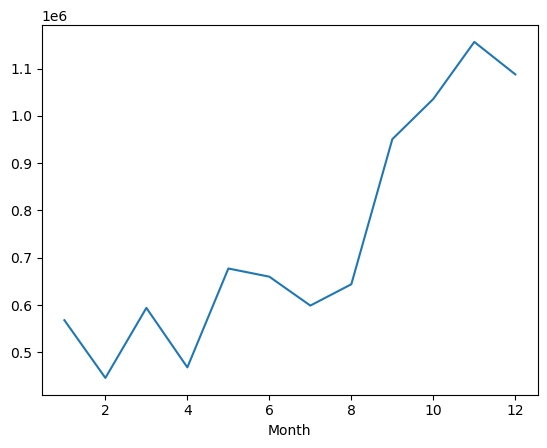

In [22]:
data.groupby('Month')['TotalAmount'].sum().plot()

We can observe by seeing the monthly trends 11 month is at peak from 8 month after peak rised i.e sales rised,,Sales spike from September → November

Likely due to:

Holiday season

Christmas preparation

Best time to target customers


<Axes: xlabel='Hour'>

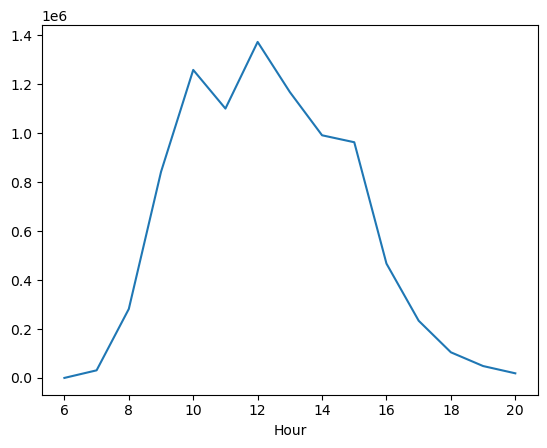

In [23]:
data.groupby('Hour')['TotalAmount'].sum().plot()

Who are our top Customers 


In [24]:
data.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalAmount, dtype: float64

Sales spike from September → November

Likely due to:

Holiday season

Christmas preparation

In [25]:
customer_data = data.groupby('CustomerID').agg({
    'TotalAmount': 'sum',
    'InvoiceNo': 'nunique'
})

In [26]:
customer_data.reset_index()

,CustomerID,TotalAmount,InvoiceNo
0,12346.0,77183.60,1
1,12347.0,4310.00,7
2,12348.0,1797.24,4
3,12349.0,1757.55,1
4,12350.0,334.40,1
...,...,...,...
4333,18280.0,180.60,1
4334,18281.0,80.82,1
4335,18282.0,178.05,2
4336,18283.0,2045.53,16


In [27]:
customer_data.columns = ['TotalSpending', 'TotalOrders']

In [28]:
df2 = data.copy()

In [29]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Month,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12,8


In [30]:
customer_data.reset_index()

,CustomerID,TotalSpending,TotalOrders
0,12346.0,77183.60,1
1,12347.0,4310.00,7
2,12348.0,1797.24,4
3,12349.0,1757.55,1
4,12350.0,334.40,1
...,...,...,...
4333,18280.0,180.60,1
4334,18281.0,80.82,1
4335,18282.0,178.05,2
4336,18283.0,2045.53,16


In [31]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [32]:
customer_data.columns

Index(['TotalSpending', 'TotalOrders'], dtype='object')

In [33]:
X = customer_data[["TotalSpending","TotalOrders"]]

In [34]:
X.head().reset_index()

,CustomerID,TotalSpending,TotalOrders
0,12346.0,77183.60,1
1,12347.0,4310.00,7
2,12348.0,1797.24,4
3,12349.0,1757.55,1
4,12350.0,334.40,1


In [35]:
ss = StandardScaler()
X_Scaled = ss.fit_transform(X)

In [36]:
X_Scaled

array([[ 8.36301037e+00, -4.25096503e-01],
       [ 2.51698905e-01,  3.54416797e-01],
       [-2.79878269e-02, -3.53398530e-02],
       ...,
       [-2.08214334e-01, -2.95177619e-01],
       [-3.51515172e-04,  1.52368675e+00],
       [-2.35311112e-02, -1.65258736e-01]], shape=(4338, 2))

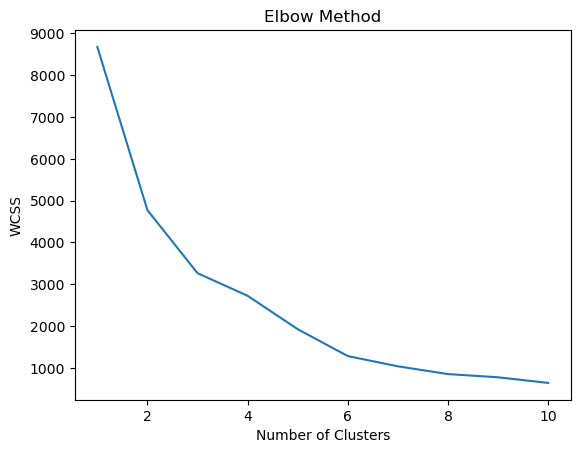

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_Scaled)   # use your variable
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [38]:
model = KMeans(n_clusters=3,random_state=42)
model.fit_predict(X_Scaled)

array([2, 0, 0, ..., 0, 2, 0], shape=(4338,), dtype=int32)

In [39]:
customer_data["cluster"] = model.labels_

In [40]:
customer_data.reset_index()

,CustomerID,TotalSpending,TotalOrders,cluster
0,12346.0,77183.60,1,2
1,12347.0,4310.00,7,0
2,12348.0,1797.24,4,0
3,12349.0,1757.55,1,0
4,12350.0,334.40,1,0
...,...,...,...,...
4333,18280.0,180.60,1,0
4334,18281.0,80.82,1,0
4335,18282.0,178.05,2,0
4336,18283.0,2045.53,16,2


In [ ]:
customer_data


In [42]:
customer_data.groupby('cluster').mean().reset_index()

,cluster,TotalSpending,TotalOrders
0,0,1096.328757,3.058421
1,1,127187.959231,82.538462
2,2,11746.514872,21.141026


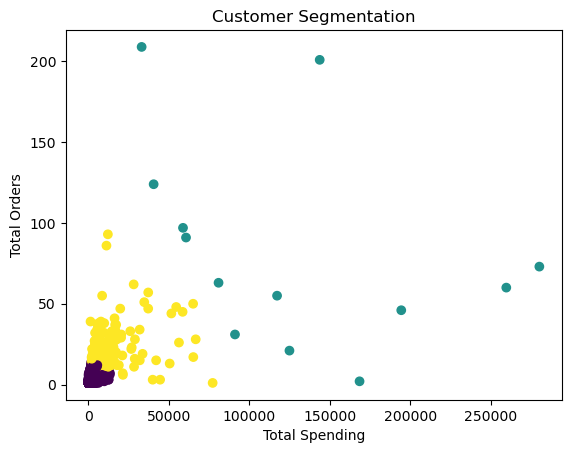

In [43]:
import matplotlib.pyplot as plt

plt.scatter(customer_data['TotalSpending'],
            customer_data['TotalOrders'],
            c=customer_data['cluster'])

plt.xlabel("Total Spending")
plt.ylabel("Total Orders")
plt.title("Customer Segmentation")
plt.show()

In [44]:
customer_data['Segment'] = customer_data['cluster'].map({
    0: "Low Value",
    1: "High Value",
    2: "Regular"
})

In [47]:
customer_data = customer_data.reset_index()
customer_data.to_csv("customer_segmentation.csv", index=False)

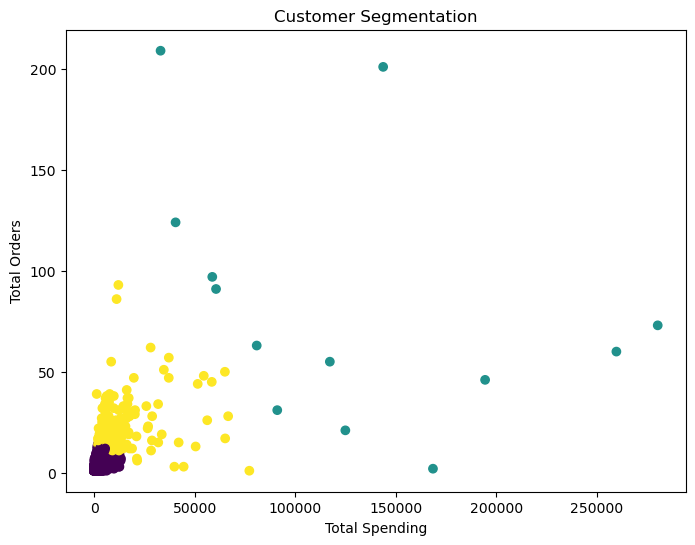

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(customer_data['TotalSpending'],
            customer_data['TotalOrders'],
            c=customer_data['cluster'])

plt.xlabel("Total Spending")
plt.ylabel("Total Orders")
plt.title("Customer Segmentation")
plt.show()

High-value customers (Cluster 1) contribute majority of revenue with high purchase frequency

Low-value customers show minimal engagement and low spending

Regular customers represent growth opportunity through targeted marketing

In [ ]:
i